### I Hyperparameters

In [7]:
# environment


# actor
ACTOR_HIDDEN_DIM = 64
ACTOR_HIDDEN_LAYER_COUNT = 0
ACTOR_LR = 1e-4

# critic
CRITIC_HIDDEN_DIM = 64
CRITIC_HIDDEN_LAYER_COUNT = 0
CRITIC_LR = 1e-3

# training
BATCH_SIZE = 100
EPISODE_COUNT = 200


### II Initialization

#### 1. Environment

In [8]:
from environment import Environment

env = Environment(
    render_mode="rgb_array",
)

env.reset()

agent_count = len(env.uavs)
state_dim = env.observation_space.shape[1]
action_dim = env.action_space.shape[1]

Show environment

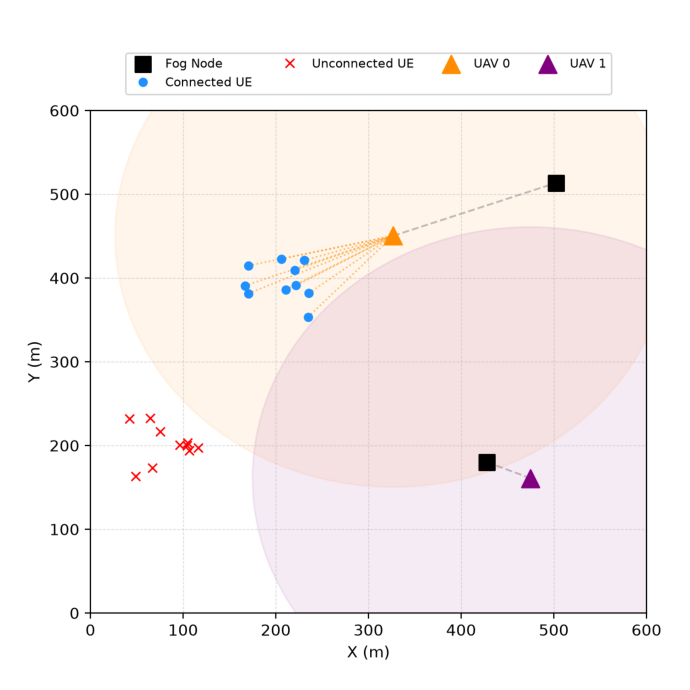

In [9]:
from matplotlib import pyplot as plt

img = env.render()
if img is not None:
    plt.figure(figsize=(7, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

#### 2. MADDPG

In [10]:
from maddpg import MADDPG
import torch

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
algorithm = MADDPG(
    agent_count=agent_count,
    state_dim=state_dim,
    action_dim=action_dim,
    actor_hidden_dim=ACTOR_HIDDEN_DIM,
    critic_hidden_dim=CRITIC_HIDDEN_DIM,
    actor_hidden_layer_count=ACTOR_HIDDEN_LAYER_COUNT,
    critic_hidden_layer_count=CRITIC_HIDDEN_LAYER_COUNT,
    actor_lr=ACTOR_LR,
    critic_lr=CRITIC_LR,
)
algorithm.to_device(device)


#### 3. Memory replay buffer

In [11]:
from memory_replay import MultiAgentBuffer

buffer = MultiAgentBuffer(
    capacity=1000000,
    agent_count=agent_count,
    state_dim=state_dim,
    action_dim=action_dim,
    device=device,
)

### III Training loop

In [12]:
import numpy as np

PRINT_INTERVAL = 10

total_steps = 0
score_history = []
avg_scores = []

for episode in range(EPISODE_COUNT):
    state, _ = env.reset()
    score = 0.0
    done = False

    while not done:
        actions = algorithm.choose_action(state)
        next_state, reward, terminated, truncated, info = env.step(actions)
        done = terminated or truncated

        buffer.push(state, actions, reward, next_state, done)

        if total_steps % 10 == 0:
            algorithm.learn(buffer, batch_size=BATCH_SIZE)

        state = next_state
        score += reward
        total_steps += 1

    score_history.append(score)
    avg_score = float(np.mean(score_history[-100:]))
    if episode % PRINT_INTERVAL == 0 and episode > 0:
        print(f"Episode {episode}, Average Score: {avg_score:.1f}")
        avg_scores.append(avg_score)

Episode 10, Average Score: -55894.6
Episode 20, Average Score: -57724.7
Episode 30, Average Score: -58663.0
Episode 40, Average Score: -59425.8
Episode 50, Average Score: -60093.5
Episode 60, Average Score: -60203.4
Episode 70, Average Score: -60126.5
Episode 80, Average Score: -59865.9
Episode 90, Average Score: -60028.9
Episode 100, Average Score: -59865.8
Episode 110, Average Score: -59990.3
Episode 120, Average Score: -59677.3
Episode 130, Average Score: -59474.1
Episode 140, Average Score: -58984.0
Episode 150, Average Score: -58435.8
Episode 160, Average Score: -58609.3
Episode 170, Average Score: -58395.8
Episode 180, Average Score: -58135.8
Episode 190, Average Score: -57576.9
